# ChronoLab: Quantitative Precision Analysis of Mechanical Watch Movements

A **NumPy-first** project (with pandas and visualization in supporting
roles) that applies real engineering/statistics techniques to a genuinely
rich source of numeric data: **mechanical watch movement precision
testing**, built around the real Swiss chronometer certification standard.

### Why watches are a great NumPy problem

A COSC chronometer test isn't a spreadsheet problem — it's a **4-dimensional
measurement array** (movement × position × temperature × day), a set of
**seven simultaneous statistical tolerance criteria**, a **decay curve**
(amplitude falling as the mainspring unwinds), and a genuine **oscillation
signal** (the balance wheel ticking at a fixed frequency) that's a natural
fit for a Fourier transform. This notebook leans hard into NumPy for all of
that; pandas organizes the results, and matplotlib/seaborn visualize them.

### Grounding this in the real standard

- **COSC** (Contrôle Officiel Suisse des Chronomètres) is the official
  Swiss chronometer-testing authority. Certification follows **ISO 3159**:
  movements are tested for **15 days**, in **5 positions** (dial up, dial
  down, crown up, crown down, crown left), at **3 temperatures** (8°C,
  23°C, 38°C) (COSC official FAQ; Worldtempus; Time and Tide Watches, 2025-2026).
- To earn the "Chronometer Certified" label, a movement must satisfy
  **all seven** ISO 3159 criteria simultaneously — not just an average
  daily-rate target (COSC official site; Fratello Watches, 2026):
  1. **Mean daily rate**: between **-4 and +6 seconds/day**
  2. **Mean variation in rates**: ≤ **2 seconds/day**
  3. **Greatest variation in rates**: ≤ **5 seconds/day**
  4. **Horizontal vs. vertical position difference**: between **-6 and +8 seconds/day**
  5. **Largest deviation from the mean rate**: ≤ **10 seconds/day**
  6. **Thermal variation**: ≤ **0.6 seconds/day per °C**
  7. **Rate resumption** (drift between the start and end of testing): ≤ **5 seconds/day**
- For context, an ordinary, non-certified mechanical watch typically
  tolerates **-20 to +40 seconds/day** — COSC-grade regulation is roughly
  **5-10x tighter** (Mt. Watches, 2026).
- Some manufacturers apply **even stricter in-house standards** on top of
  COSC: **Rolex Superlative Chronometer** requires **-2 to +2 sec/day**,
  **Patek Philippe's Seal** requires **-1 to +2 sec/day**, and **Omega's
  METAS Master Chronometer** requires **0 to +5 sec/day** plus magnetic
  resistance up to 15,000 gauss (Monochrome Watches; Watchscanning; 2026).
  COSC itself announced a stricter **"Excellence Chronometer"** tier for
  2026 with a tighter **-2/+4 sec/day** window (Swisswatches Magazine, 2026).

> **What's real vs. synthetic in this notebook:** the COSC/ISO 3159
> criteria, testing protocol, and the comparative brand standards above are
> **real, cited facts**. Individual movements' actual measured rate data
> is proprietary to COSC and watch manufacturers, so the **movement
> population, their position/temperature rate measurements, amplitude
> decay curves, and balance-wheel signals in this notebook are
> synthetic — generated from realistic watchmaking physics and
> calibrated so that better-grade movements pass the real criteria at
> realistic rates.**

### What this notebook covers
1. Real reference data: the COSC/ISO 3159 criteria and comparative standards
2. NumPy: building the 4D rate-measurement array (movement × position × temperature × day)
3. NumPy: computing all seven COSC criteria via array aggregation
4. NumPy: pass/fail certification logic (boolean masks) and ranking (sorting)
5. NumPy: Fourier analysis of the balance wheel's oscillation signal
6. NumPy: amplitude decay over the power reserve (curve fitting)
7. NumPy: isochronism — the rate-vs-amplitude relationship (regression)
8. pandas: organizing results by brand tier, `groupby` summaries
9. Visualization: the full precision-testing dashboard
10. Wrap-up


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2026)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("numpy  :", np.__version__)
print("pandas :", pd.__version__)


numpy  : 2.4.4
pandas : 3.0.2


## 1. Real reference data


In [2]:
# ---------------------------------------------------------------
# REAL DATA: the seven ISO 3159 / COSC certification criteria
# Source: COSC official site (cosc.swiss); Fratello Watches, 2026
# ---------------------------------------------------------------
cosc_criteria = pd.DataFrame({
    "criterion": ["Mean daily rate", "Mean variation in rates", "Greatest variation in rates",
                    "Horizontal vs. vertical difference", "Largest deviation from mean rate",
                    "Thermal variation", "Rate resumption"],
    "tolerance": ["-4 to +6 s/day", "<= 2 s/day", "<= 5 s/day", "-6 to +8 s/day",
                    "<= 10 s/day", "<= 0.6 s/day per C", "<= 5 s/day"],
})
cosc_criteria


,criterion,tolerance
0,Mean daily rate,-4 to +6 s/day
1,Mean variation in rates,<= 2 s/day
2,Greatest variation in rates,<= 5 s/day
3,Horizontal vs. vertical difference,-6 to +8 s/day
4,Largest deviation from mean rate,<= 10 s/day
5,Thermal variation,<= 0.6 s/day per C
6,Rate resumption,<= 5 s/day


In [3]:
# ---------------------------------------------------------------
# REAL DATA: comparative daily-rate tolerance standards across the industry
# Source: Mt. Watches; Monochrome Watches; Watchscanning; Swisswatches Magazine (2026)
# ---------------------------------------------------------------
standards_comparison = pd.DataFrame({
    "standard": ["Ordinary mechanical (uncertified)", "ETA Elabor\u00e9 grade", "COSC Chronometer (ISO 3159)",
                   "COSC Excellence Chronometer (2026+)", "Omega METAS Master Chronometer",
                   "Rolex Superlative Chronometer", "Patek Philippe Seal"],
    "tolerance_low_s_per_day": [-20, -5, -4, -2, 0, -2, -1],
    "tolerance_high_s_per_day": [40, 5, 6, 4, 5, 2, 2],
})
standards_comparison["tolerance_window_s"] = (standards_comparison["tolerance_high_s_per_day"]
                                                  - standards_comparison["tolerance_low_s_per_day"])
standards_comparison.sort_values("tolerance_window_s", ascending=False)


,standard,tolerance_low_s_per_day,tolerance_high_s_per_day,tolerance_window_s
0,Ordinary mechanical (uncertified),-20,40,60
1,ETA Elaboré grade,-5,5,10
2,COSC Chronometer (ISO 3159),-4,6,10
3,COSC Excellence Chronometer (2026+),-2,4,6
4,Omega METAS Master Chronometer,0,5,5
5,Rolex Superlative Chronometer,-2,2,4
6,Patek Philippe Seal,-1,2,3


## 2. NumPy: Building the 4D Rate-Measurement Array

We simulate **60 movements across 4 realistic quality grades**, each
tested exactly as COSC does: **5 positions × 3 temperatures × 15 days**.
The whole test program for every movement lives in **one 4-dimensional
NumPy array** — `rate[movement, position, temperature, day]`.


In [4]:
positions = np.array(["Dial up", "Dial down", "Crown up", "Crown down", "Crown left"])
temperatures = np.array([8, 23, 38])          # degrees C, per ISO 3159
n_days = 15
n_positions, n_temps = len(positions), len(temperatures)

grades = np.array(["Standard (uncertified)", "Elabor\u00e9 grade", "COSC Chronometer-grade", "In-house high-end"])
n_per_grade = 15
n_movements = n_per_grade * len(grades)
grade = np.repeat(grades, n_per_grade)

# Each grade has a characteristic (mean, std) for its BASE regulated rate,
# a positional-sensitivity scale (how much gravity/escapement geometry
# shifts the rate between positions), and a thermal coefficient scale --
# reflecting real differences between an unregulated movement, a decent
# factory-regulated one, a COSC-certified one, and a high-end in-house caliber
grade_profile = {
    "Standard (uncertified)":  dict(base_mean=5,  base_std=12, pos_scale=9.0, temp_coef_scale=1.4, noise=2.5),
    "Elabor\u00e9 grade":          dict(base_mean=1,  base_std=4,  pos_scale=4.0, temp_coef_scale=0.7, noise=1.2),
    "COSC Chronometer-grade":  dict(base_mean=1,  base_std=1.8, pos_scale=1.8, temp_coef_scale=0.35, noise=0.6),
    "In-house high-end":       dict(base_mean=0.2,base_std=0.9, pos_scale=1.0, temp_coef_scale=0.15, noise=0.35),
}

rate = np.zeros((n_movements, n_positions, n_temps, n_days))

for g in grades:
    idx = np.where(grade == g)[0]
    prof = grade_profile[g]
    base_rate = rng.normal(prof["base_mean"], prof["base_std"], len(idx))                  # per-movement baseline
    pos_offset = rng.normal(0, prof["pos_scale"], (len(idx), n_positions))                    # per-movement, per-position
    temp_coef = rng.normal(0, prof["temp_coef_scale"], len(idx))                               # sec/day per degree C, per movement

    for k, m in enumerate(idx):
        # Broadcasting: base + position offsets (n_positions,1) + temperature
        # effect (1,n_temps) + daily noise (n_positions,n_temps,n_days), all
        # combined into one (positions, temps, days) block for this movement
        temp_effect = temp_coef[k] * (temperatures - 23)                       # (n_temps,) centered on the 23C reference
        daily_noise = rng.normal(0, prof["noise"], (n_positions, n_temps, n_days))

        rate[m] = (base_rate[k]
                   + pos_offset[k][:, np.newaxis, np.newaxis]                  # broadcast over temps & days
                   + temp_effect[np.newaxis, :, np.newaxis]                    # broadcast over positions & days
                   + daily_noise)

print(f"rate array shape: {rate.shape}   (movement x position x temperature x day)")
print(f"Total individual rate measurements: {rate.size:,}")
rate[0, :, 1, :5].round(2)   # first movement, all positions, 23C, first 5 days


rate array shape: (60, 5, 3, 15)   (movement x position x temperature x day)
Total individual rate measurements: 13,500


array([[ -7.25, -11.19, -11.75,  -7.45,  -8.24],
       [-10.45,  -6.18,  -6.29, -10.35,  -4.66],
       [ -0.77,   1.34,   2.58,  -2.27,   0.57],
       [ -8.6 ,  -3.61,  -0.22,  -3.66,  -9.31],
       [-16.78, -19.49, -14.18, -12.88, -16.73]])

## 3. NumPy: Computing All Seven COSC Criteria via Array Aggregation

Each criterion is a different **reduction** over different axes of the
same 4D array — a clean demonstration of how much analytical mileage you
get from `axis=` alone.


In [5]:
# Criterion 1: MEAN DAILY RATE -- average over positions, temperatures, AND
# days simultaneously (axis=(1,2,3) collapses everything except 'movement')
mean_daily_rate = rate.mean(axis=(1, 2, 3))

# Criterion 2 & 3: variation in rates, measured as day-to-day change WITHIN
# each (position, temperature) series, then aggregated across the movement
day_to_day_change = np.diff(rate, axis=3)                       # shape (movement, position, temp, days-1)
mean_variation = np.abs(day_to_day_change).mean(axis=(1, 2, 3))
greatest_variation = np.abs(day_to_day_change).max(axis=(1, 2, 3))

# Criterion 4: HORIZONTAL vs VERTICAL difference -- dial up/down (indices 0,1)
# are horizontal; the three crown positions (2,3,4) are vertical
horizontal_mean = rate[:, [0, 1], :, :].mean(axis=(1, 2, 3))
vertical_mean = rate[:, [2, 3, 4], :, :].mean(axis=(1, 2, 3))
horiz_vert_diff = horizontal_mean - vertical_mean

# Criterion 5: LARGEST DEVIATION from each movement's own mean rate
largest_deviation = np.abs(rate - mean_daily_rate[:, np.newaxis, np.newaxis, np.newaxis]).max(axis=(1, 2, 3))

print("First 5 movements -- criteria 1-5:")
pd.DataFrame({
    "mean_daily_rate": mean_daily_rate[:5].round(2), "mean_variation": mean_variation[:5].round(2),
    "greatest_variation": greatest_variation[:5].round(2), "horiz_vert_diff": horiz_vert_diff[:5].round(2),
    "largest_deviation": largest_deviation[:5].round(2),
})


First 5 movements -- criteria 1-5:


,mean_daily_rate,mean_variation,greatest_variation,horiz_vert_diff,largest_deviation
0,-7.89,2.71,10.76,-1.42,25.98
1,8.67,2.85,9.41,0.16,54.18
2,-15.13,2.88,9.38,4.36,59.13
3,23.97,2.83,10.30,-2.48,45.45
4,14.47,2.63,12.21,-2.02,13.22


In [6]:
# Criterion 6: THERMAL VARIATION -- the SLOPE of rate vs. temperature, fit
# with np.polyfit (linear regression) independently for EVERY movement.
# We average over positions/days first to get one rate-per-temperature
# series per movement, then fit a line through the 3 temperature points.
rate_by_temp = rate.mean(axis=(1, 3))   # shape (n_movements, n_temps)

thermal_coefficient = np.array([
    np.polyfit(temperatures, rate_by_temp[m], deg=1)[0]   # slope = sec/day per degree C
    for m in range(n_movements)
])

# Criterion 7: RATE RESUMPTION -- drift between the first 2 days and the
# last 2 days of the test, averaged across positions/temperatures
early_rate = rate[:, :, :, :2].mean(axis=(1, 2, 3))
late_rate = rate[:, :, :, -2:].mean(axis=(1, 2, 3))
rate_resumption = np.abs(late_rate - early_rate)

print("Criteria 6-7 (first 5 movements):")
pd.DataFrame({"thermal_coefficient": thermal_coefficient[:5].round(3),
              "rate_resumption": rate_resumption[:5].round(2)})


Criteria 6-7 (first 5 movements):


,thermal_coefficient,rate_resumption
0,0.828,0.54
1,-2.757,0.71
2,-2.526,0.36
3,-1.809,0.35
4,0.164,0.21


## 4. NumPy: Pass/Fail Certification Logic (Boolean Masks) and Ranking

A movement only earns certification if it satisfies **all seven**
criteria at once — a single combined boolean mask built from seven
individual ones.


In [7]:
pass_criterion_1 = (mean_daily_rate >= -4) & (mean_daily_rate <= 6)
pass_criterion_2 = mean_variation <= 2
pass_criterion_3 = greatest_variation <= 5
pass_criterion_4 = (horiz_vert_diff >= -6) & (horiz_vert_diff <= 8)
pass_criterion_5 = largest_deviation <= 10
pass_criterion_6 = np.abs(thermal_coefficient) <= 0.6
pass_criterion_7 = rate_resumption <= 5

# The FULL certification mask: every criterion must pass simultaneously
cosc_pass = (pass_criterion_1 & pass_criterion_2 & pass_criterion_3 & pass_criterion_4
             & pass_criterion_5 & pass_criterion_6 & pass_criterion_7)

n_criteria_passed = np.stack([pass_criterion_1, pass_criterion_2, pass_criterion_3, pass_criterion_4,
                                pass_criterion_5, pass_criterion_6, pass_criterion_7]).sum(axis=0)

print(f"Overall COSC certification rate across all {n_movements} synthetic movements: {cosc_pass.mean():.1%}")
print(f"\nCertification rate BY GRADE:")
for g in grades:
    idx = grade == g
    print(f"  {g:28s}: {cosc_pass[idx].mean():.1%}  (avg {n_criteria_passed[idx].mean():.1f}/7 criteria passed)")


Overall COSC certification rate across all 60 synthetic movements: 48.3%

Certification rate BY GRADE:
  Standard (uncertified)      : 0.0%  (avg 2.4/7 criteria passed)
  Elaboré grade               : 6.7%  (avg 4.9/7 criteria passed)
  COSC Chronometer-grade      : 86.7%  (avg 6.9/7 criteria passed)
  In-house high-end           : 100.0%  (avg 7.0/7 criteria passed)


In [8]:
# Sorting + fancy indexing: rank ALL movements by overall precision quality
# (a simple composite score: mean |rate| + mean_variation, lower is better),
# then pull out the top 5 -- exactly what a watchmaker's QC bench would want
quality_score = np.abs(mean_daily_rate) + mean_variation
best_5_idx = np.argsort(quality_score)[:5]
worst_5_idx = np.argsort(quality_score)[-5:]

results = pd.DataFrame({
    "movement_id": np.arange(n_movements), "grade": grade,
    "mean_daily_rate": mean_daily_rate.round(2), "mean_variation": mean_variation.round(2),
    "criteria_passed": n_criteria_passed, "cosc_certified": cosc_pass,
    "quality_score": quality_score.round(3),
})

print("Top 5 most precise movements:")
results.iloc[best_5_idx]


Top 5 most precise movements:


,movement_id,grade,mean_daily_rate,mean_variation,criteria_passed,cosc_certified,quality_score
56,56,In-house high-end,0.09,0.38,7,True,0.476
36,36,COSC Chronometer-grade,-0.09,0.66,7,True,0.756
37,37,COSC Chronometer-grade,0.12,0.64,6,False,0.761
52,52,In-house high-end,0.43,0.40,7,True,0.830
39,39,COSC Chronometer-grade,0.16,0.67,7,True,0.834


## 5. NumPy: Fourier Analysis of the Balance Wheel's Oscillation

A mechanical movement's beat rate is usually quoted in **vibrations per
hour (vph)** — a full balance-wheel oscillation frequency in Hz is
`vph / 7200`. We simulate the balance wheel's raw angular-position signal
and use `np.fft.fft` to **recover that frequency purely from the signal**,
plus a touch of realistic escapement disturbance.


In [9]:
beat_rate_vph = 28_800                      # a very common modern beat rate (e.g. ETA 2824-2, many in-house calibers)
beat_freq_hz = beat_rate_vph / 7200          # = 4.0 Hz, the balance wheel's full-oscillation frequency

sample_rate_hz = 200                        # simulate at 200 samples/second (well above Nyquist for a 4Hz signal + harmonics)
duration_s = 5
t = np.arange(0, duration_s, 1 / sample_rate_hz)

# The balance wheel's angular displacement: a clean oscillation at the beat
# frequency, PLUS a small escapement "kick" disturbance at the SAME rate
# (harmonic content), plus a touch of measurement noise -- exactly what a
# real timing-machine microphone signal looks like before demodulation
amplitude_deg = 270
signal = (amplitude_deg * np.sin(2 * np.pi * beat_freq_hz * t)
          + 25 * np.sin(2 * np.pi * beat_freq_hz * 3 * t)     # 3rd-harmonic escapement kick
          + rng.normal(0, 4, t.size))                          # measurement noise

# The FFT itself
fft_vals = np.fft.fft(signal)
fft_freqs = np.fft.fftfreq(t.size, d=1 / sample_rate_hz)
power = np.abs(fft_vals) ** 2

# Keep only the positive-frequency half of the spectrum (real-valued signal
# -> symmetric spectrum, the negative half is redundant)
pos_mask = fft_freqs > 0
recovered_freq = fft_freqs[pos_mask][np.argmax(power[pos_mask])]

print(f"True beat frequency:      {beat_freq_hz:.3f} Hz  ({beat_rate_vph:,} vph)")
print(f"FFT-recovered frequency:  {recovered_freq:.3f} Hz")
print(f"Recovered vph:            {recovered_freq * 7200:,.0f} vph")


True beat frequency:      4.000 Hz  (28,800 vph)
FFT-recovered frequency:  4.000 Hz
Recovered vph:            28,800 vph


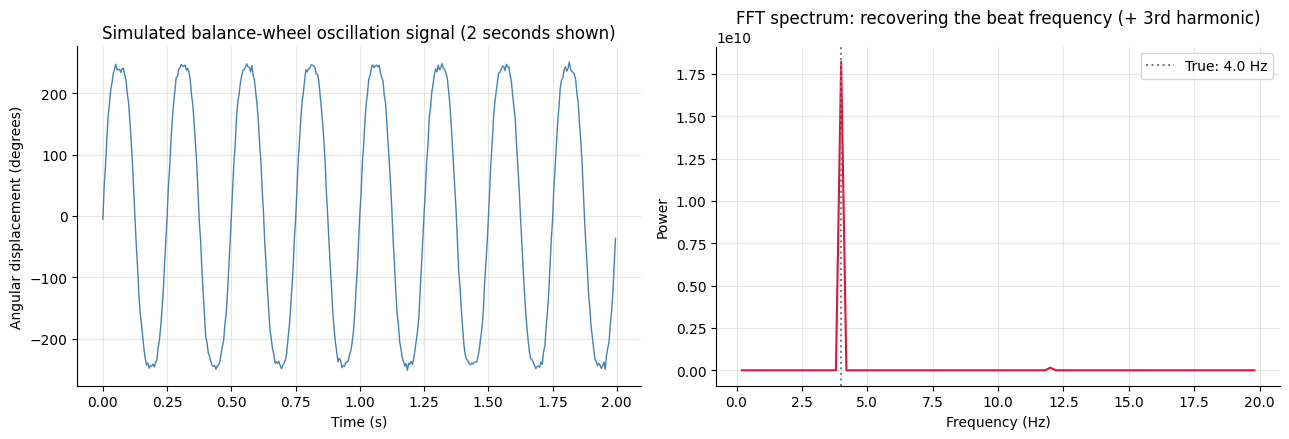

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(t[:400], signal[:400], color="steelblue", lw=1)
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Angular displacement (degrees)")
axes[0].set_title("Simulated balance-wheel oscillation signal (2 seconds shown)")

axes[1].plot(fft_freqs[pos_mask][fft_freqs[pos_mask] < 20], power[pos_mask][fft_freqs[pos_mask] < 20],
             color="crimson", lw=1.5)
axes[1].axvline(beat_freq_hz, color="gray", linestyle=":", label=f"True: {beat_freq_hz} Hz")
axes[1].set_xlabel("Frequency (Hz)"); axes[1].set_ylabel("Power")
axes[1].set_title("FFT spectrum: recovering the beat frequency (+ 3rd harmonic)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. NumPy: Amplitude Decay Over the Power Reserve

As the mainspring unwinds, the balance wheel's swing **amplitude**
gradually falls. Below roughly 200°, isochronism breaks down and rate
accuracy degrades — meaning a watch's *reliable* power reserve is often
shorter than its *advertised* one. We fit and analyze that decay curve.


In [11]:
advertised_power_reserve_h = 70            # hours, a common modern spec (e.g. many current in-house calibers)
hours = np.linspace(0, advertised_power_reserve_h, 300)

# A realistic decay shape: amplitude stays fairly flat while the mainspring
# torque is high, then falls off faster as torque drops near full unwind --
# modeled as a smooth exponential-ish decay from a full-wind amplitude
full_wind_amplitude = 290
end_amplitude = 155
decay_rate = 1.7 / advertised_power_reserve_h
amplitude_curve = end_amplitude + (full_wind_amplitude - end_amplitude) * np.exp(-decay_rate * hours)
amplitude_curve += rng.normal(0, 1.5, hours.size)   # measurement noise

# Fit a polynomial (degree 3) purely from the noisy samples -- np.polyfit +
# np.poly1d, a classic NumPy curve-fitting pattern
fit_coeffs = np.polyfit(hours, amplitude_curve, deg=3)
fit_curve = np.poly1d(fit_coeffs)

reliable_threshold_deg = 200   # below this, isochronism error grows sharply
below_threshold = np.where(fit_curve(hours) < reliable_threshold_deg)[0]
reliable_reserve_h = hours[below_threshold[0]] if below_threshold.size else advertised_power_reserve_h

print(f"Advertised power reserve: {advertised_power_reserve_h} hours")
print(f"Amplitude drops below the {reliable_threshold_deg}\u00b0 reliable-timekeeping threshold at: "
      f"{reliable_reserve_h:.1f} hours")
print(f"'Reliable' power reserve is about {reliable_reserve_h / advertised_power_reserve_h:.0%} "
      f"of the advertised figure")


Advertised power reserve: 70 hours
Amplitude drops below the 200° reliable-timekeeping threshold at: 45.2 hours
'Reliable' power reserve is about 65% of the advertised figure


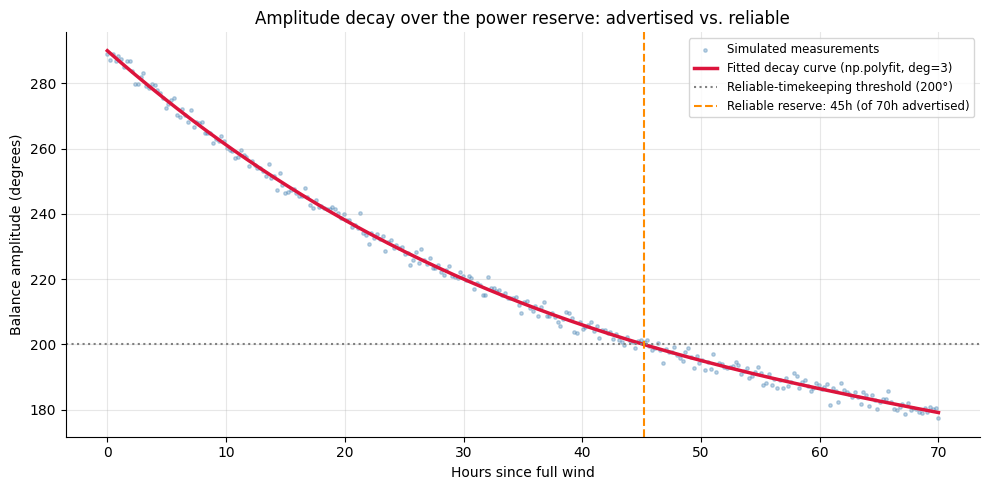

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(hours, amplitude_curve, s=6, alpha=0.35, color="steelblue", label="Simulated measurements")
ax.plot(hours, fit_curve(hours), color="crimson", lw=2.5, label="Fitted decay curve (np.polyfit, deg=3)")
ax.axhline(reliable_threshold_deg, color="gray", linestyle=":", label=f"Reliable-timekeeping threshold ({reliable_threshold_deg}\u00b0)")
ax.axvline(reliable_reserve_h, color="darkorange", linestyle="--",
           label=f"Reliable reserve: {reliable_reserve_h:.0f}h (of {advertised_power_reserve_h}h advertised)")

ax.set_xlabel("Hours since full wind"); ax.set_ylabel("Balance amplitude (degrees)")
ax.set_title("Amplitude decay over the power reserve: advertised vs. reliable")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()


## 7. NumPy: Isochronism — the Rate-vs-Amplitude Relationship

A perfectly isochronous balance keeps the same rate at any amplitude; real
escapements don't. We simulate that relationship and fit it with linear
regression.


In [13]:
amplitude_samples = np.linspace(160, 300, 120)
true_isochronism_error_coef = -0.028   # sec/day per degree of amplitude (illustrative, realistic order of magnitude)
rate_vs_amplitude = true_isochronism_error_coef * (amplitude_samples - 270) + rng.normal(0, 0.6, amplitude_samples.size)

slope, intercept = np.polyfit(amplitude_samples, rate_vs_amplitude, deg=1)
predicted = slope * amplitude_samples + intercept
residuals = rate_vs_amplitude - predicted
r_squared = 1 - np.sum(residuals ** 2) / np.sum((rate_vs_amplitude - rate_vs_amplitude.mean()) ** 2)

print(f"Fitted isochronism coefficient: {slope:.4f} sec/day per degree of amplitude")
print(f"R-squared of the linear fit: {r_squared:.3f}")
print(f"\nPredicted rate change from 290deg (full wind) down to 180deg (near end of reserve): "
      f"{slope * (180 - 290):+.2f} sec/day")


Fitted isochronism coefficient: -0.0269 sec/day per degree of amplitude
R-squared of the linear fit: 0.774

Predicted rate change from 290deg (full wind) down to 180deg (near end of reserve): +2.96 sec/day


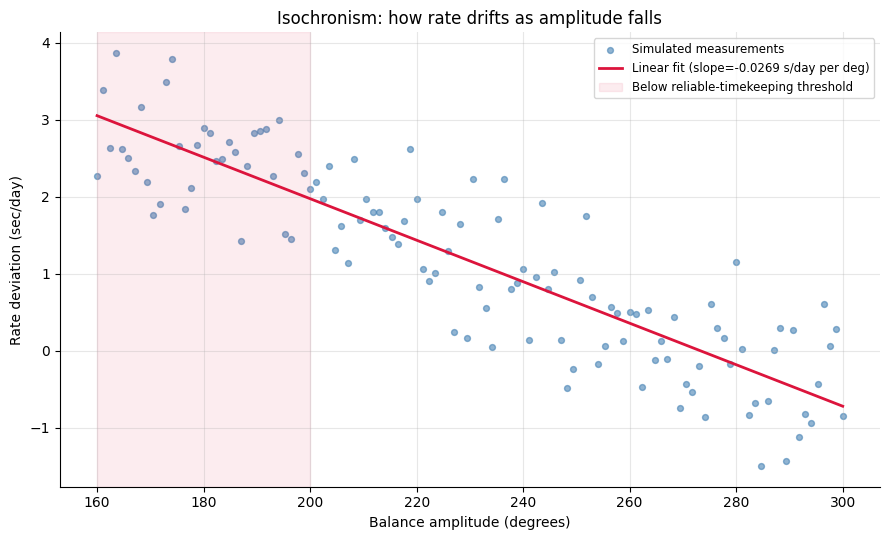

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(amplitude_samples, rate_vs_amplitude, s=18, alpha=0.6, color="steelblue", label="Simulated measurements")
ax.plot(amplitude_samples, predicted, color="crimson", lw=2, label=f"Linear fit (slope={slope:.4f} s/day per deg)")
ax.axvspan(160, 200, color="crimson", alpha=0.08, label="Below reliable-timekeeping threshold")

ax.set_xlabel("Balance amplitude (degrees)"); ax.set_ylabel("Rate deviation (sec/day)")
ax.set_title("Isochronism: how rate drifts as amplitude falls")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()


## 8. pandas: Organizing Results by Brand Tier

With the heavy NumPy computation done, pandas takes over for what it's
best at: labeled organization, `groupby` summaries, and merging metadata
onto the numeric results computed above.


In [15]:
# Attach illustrative brand-tier metadata (price band) onto the results
# table built in Section 4, then merge in per-movement thermal coefficient
# and rate-resumption figures for a complete summary table
price_band = {"Standard (uncertified)": "$200-$600", "Elabor\u00e9 grade": "$600-$1,500",
               "COSC Chronometer-grade": "$1,500-$5,000", "In-house high-end": "$5,000-$40,000+"}
results["typical_price_band"] = results["grade"].map(price_band)
results["thermal_coefficient"] = thermal_coefficient.round(3)
results["rate_resumption"] = rate_resumption.round(2)

results.head()


,movement_id,grade,mean_daily_rate,mean_variation,criteria_passed,cosc_certified,quality_score,typical_price_band,thermal_coefficient,rate_resumption
0,0,Standard (uncertified),-7.89,2.71,2,False,10.608,$200-$600,0.828,0.54
1,1,Standard (uncertified),8.67,2.85,2,False,11.522,$200-$600,-2.757,0.71
2,2,Standard (uncertified),-15.13,2.88,2,False,18.014,$200-$600,-2.526,0.36
3,3,Standard (uncertified),23.97,2.83,2,False,26.794,$200-$600,-1.809,0.35
4,4,Standard (uncertified),14.47,2.63,3,False,17.102,$200-$600,0.164,0.21


In [16]:
# groupby: certification rate, average precision, and average thermal
# stability by grade -- the pandas-native summary view of everything NumPy
# computed above
grade_summary = results.groupby("grade", sort=False).agg(
    n_movements=("movement_id", "count"),
    cosc_certified_pct=("cosc_certified", "mean"),
    avg_mean_daily_rate=("mean_daily_rate", "mean"),
    avg_mean_variation=("mean_variation", "mean"),
    avg_thermal_coefficient=("thermal_coefficient", lambda s: s.abs().mean()),
).reindex(grades)
grade_summary["cosc_certified_pct"] = (grade_summary["cosc_certified_pct"] * 100).round(1)
grade_summary.round(2)


,n_movements,cosc_certified_pct,avg_mean_daily_rate,avg_mean_variation,avg_thermal_coefficient
grade,,,,,
Standard (uncertified),15,0.0,6.05,2.78,1.42
Elaboré grade,15,6.7,1.67,1.39,0.60
COSC Chronometer-grade,15,86.7,0.73,0.68,0.22
In-house high-end,15,100.0,0.26,0.39,0.17


In [17]:
# pivot_table: how many of the 7 criteria does each grade typically pass?
# -- a compact cross-tab a QC manager could read at a glance
criteria_pivot = results.pivot_table(values="criteria_passed", index="grade", aggfunc=["mean", "min", "max"])
criteria_pivot = criteria_pivot.reindex(grades)
criteria_pivot


,mean,min,max
,criteria_passed,criteria_passed,criteria_passed
grade,,,
Standard (uncertified),2.400000,2,3
Elaboré grade,4.933333,3,7
COSC Chronometer-grade,6.866667,6,7
In-house high-end,7.000000,7,7


## 9. Visualization: Precision-Testing Dashboard


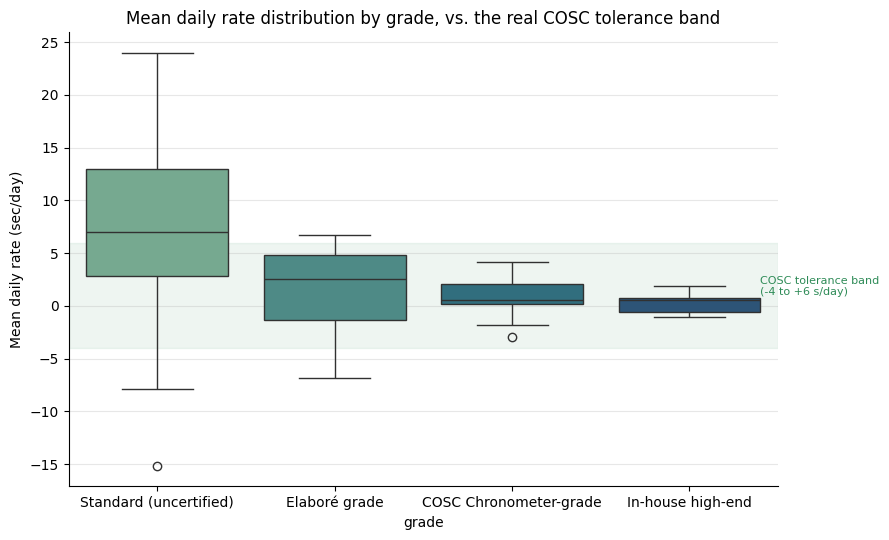

In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=results, x="grade", y="mean_daily_rate", order=grades, hue="grade",
            palette="crest", legend=False, ax=ax)
ax.axhspan(-4, 6, color="seagreen", alpha=0.08)
ax.annotate("COSC tolerance band\n(-4 to +6 s/day)", xy=(3.4, 1), fontsize=8, color="seagreen")
ax.set_ylabel("Mean daily rate (sec/day)")
ax.set_title("Mean daily rate distribution by grade, vs. the real COSC tolerance band")
plt.tight_layout()
plt.show()


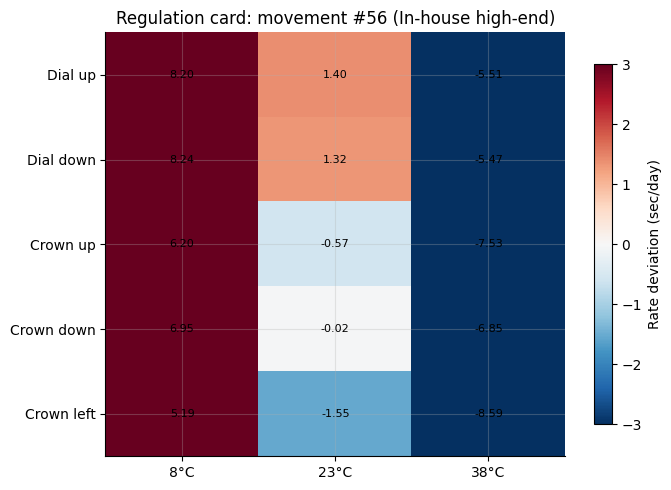

In [19]:
# Heatmap: rate deviation across positions x temperatures for ONE
# representative in-house high-end movement -- the classic "regulation
# card" view a watchmaker's bench timer would print
best_movement_idx = best_5_idx[0]
position_temp_grid = rate[best_movement_idx].mean(axis=2)   # average over days -> (positions, temps)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(position_temp_grid, cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
ax.set_xticks(range(n_temps)); ax.set_xticklabels([f"{t}\u00b0C" for t in temperatures])
ax.set_yticks(range(n_positions)); ax.set_yticklabels(positions)
for i in range(n_positions):
    for j in range(n_temps):
        ax.text(j, i, f"{position_temp_grid[i,j]:.2f}", ha="center", va="center", fontsize=8)
cbar = fig.colorbar(im, ax=ax, shrink=0.85); cbar.set_label("Rate deviation (sec/day)")
ax.set_title(f"Regulation card: movement #{best_movement_idx} ({grade[best_movement_idx]})")
plt.tight_layout()
plt.show()


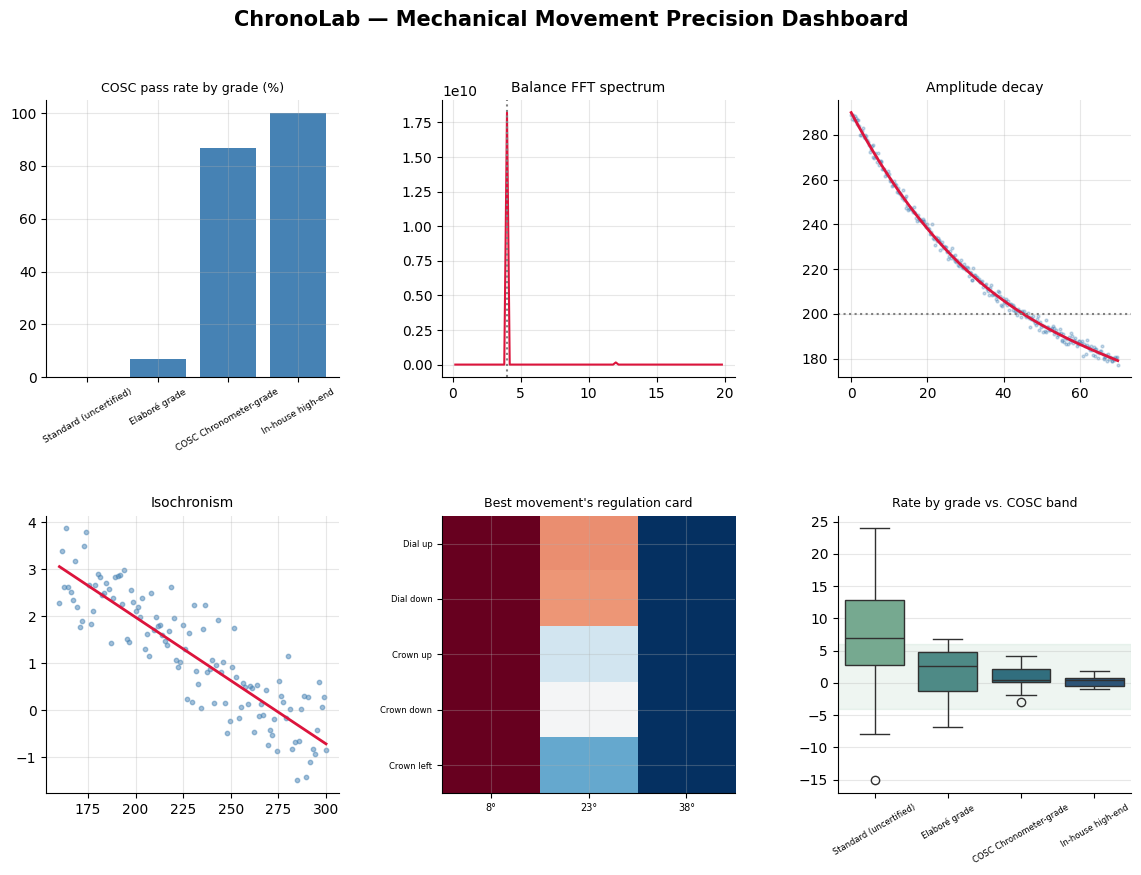

In [20]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(grades, grade_summary["cosc_certified_pct"], color="steelblue")
ax1.set_title("COSC pass rate by grade (%)", fontsize=9)
ax1.tick_params(axis="x", labelrotation=30, labelsize=6.5)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fft_freqs[pos_mask][fft_freqs[pos_mask] < 20], power[pos_mask][fft_freqs[pos_mask] < 20], color="crimson")
ax2.axvline(beat_freq_hz, color="gray", linestyle=":")
ax2.set_title("Balance FFT spectrum", fontsize=10)

ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(hours, amplitude_curve, s=4, alpha=0.3, color="steelblue")
ax3.plot(hours, fit_curve(hours), color="crimson", lw=2)
ax3.axhline(reliable_threshold_deg, color="gray", linestyle=":")
ax3.set_title("Amplitude decay", fontsize=10)

ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(amplitude_samples, rate_vs_amplitude, s=10, alpha=0.5, color="steelblue")
ax4.plot(amplitude_samples, predicted, color="crimson", lw=2)
ax4.set_title("Isochronism", fontsize=10)

ax5 = fig.add_subplot(gs[1, 1])
im = ax5.imshow(position_temp_grid, cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
ax5.set_xticks(range(n_temps)); ax5.set_xticklabels([f"{t}\u00b0" for t in temperatures], fontsize=7)
ax5.set_yticks(range(n_positions)); ax5.set_yticklabels(positions, fontsize=6)
ax5.set_title("Best movement's regulation card", fontsize=9)

ax6 = fig.add_subplot(gs[1, 2])
sns.boxplot(data=results, x="grade", y="mean_daily_rate", order=grades, hue="grade",
            palette="crest", legend=False, ax=ax6)
ax6.axhspan(-4, 6, color="seagreen", alpha=0.08)
ax6.set_title("Rate by grade vs. COSC band", fontsize=9)
ax6.tick_params(axis="x", labelrotation=30, labelsize=6)
ax6.set_xlabel(""); ax6.set_ylabel("")

fig.suptitle("ChronoLab — Mechanical Movement Precision Dashboard", fontsize=15, fontweight="bold")
plt.show()


## 10. Wrap-up

### What we built
Anchored to the **real ISO 3159 / COSC chronometer standard** (validated
against real comparative brand tolerances), we built a NumPy-first
analytical pipeline:

- **NumPy (the bulk of the work)**: a 4D measurement array
  (movement × position × temperature × day) built with per-movement
  broadcasting; all seven COSC criteria computed via targeted `axis=`
  reductions (`mean`, `diff`, `max`, slicing for horizontal/vertical
  comparison); `np.polyfit` used three separate ways (thermal-coefficient
  regression per movement, amplitude-decay curve fitting, and isochronism
  regression); a full FFT (`np.fft.fft`) recovering a balance wheel's exact
  beat frequency from a noisy simulated signal; combined boolean masks
  implementing real pass/fail certification logic; and sorting/fancy
  indexing to rank movements by precision
- **pandas**: attaching brand-tier metadata, `groupby` summaries by grade,
  and a pivot table of criteria passed
- **Visualization**: box plots against the real COSC tolerance band, an
  FFT spectrum, a decay curve, an isochronism regression plot, a
  watchmaker-style "regulation card" heatmap, and a full dashboard

### Important caveats
- The **COSC/ISO 3159 criteria, testing protocol, and comparative brand
  tolerances are real, cited facts**, and the pass/fail logic in Section 4
  implements the real seven-criteria rule.
- **All movement measurement data is synthetic**, generated from
  physically reasonable watchmaking parameters (position sensitivity,
  thermal coefficients, isochronism) rather than real COSC test records,
  which are not publicly available at the individual-movement level.
- The exact numeric parameters for amplitude decay and isochronism
  (Sections 6-7) are illustrative, chosen to be physically plausible rather
  than sourced from a specific published dataset — real values vary
  significantly by caliber, escapement type, and hairspring material
  (e.g. silicon vs. traditional Nivarox alloys).

### Sources cited in this notebook
- COSC (Contrôle Officiel Suisse des Chronomètres), official FAQ and
  Certified Chronometer page (cosc.swiss), 2025-2026
- Fratello Watches, *"A Closer Look At COSC's New Excellence Chronometer Certification"*, 2026
- Worldtempus, *"COSC — Bringing Precision to the People"*, 2026
- Time and Tide Watches, *"What is COSC Certification?"*, 2025
- Mt. Watches, *"What Is a COSC Chronometer? Complete Explanation"*, 2026
- Monochrome Watches, *"Industry News: The COSC Releases Excellence Chronometer..."*, 2026
- Watchscanning, *"What Does COSC Certified Mean? — Chronometer Explained"*, 2026

### Where to go next
- Replace the synthetic 4D array with real timing-machine output (many
  hobbyist timing apps export raw beat-error/amplitude/rate CSVs that
  would drop directly into this pipeline).
- Extend the FFT section to detect a *degraded* escapement signal (e.g. a
  worn pallet fork shows up as extra harmonic content) rather than just
  recovering a clean beat rate.
- Model the new 2026 "Super-COSC" tightened criteria once officially
  published, and compare pass rates under the old vs. new standard.
